# Here, I am going to be plotting data for 3 participants together

In [15]:
from metamers.eeg.ssvep2python import  load_ssvep_npz
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd

# where is the data
targetFoder = "/home/zevaz/projects/metamers/eeg/ssvepBLUETEST"

# sub 1
fname    = "MET000TESTBLUEBlueTest.mat"
npz_path = os.path.join(targetFoder, fname.replace(".mat", ".npz"))
ssvep1 =load_ssvep_npz(npz_path)

# sub 2
fname    = "MET003TESTBLUEBlueTest.mat"
npz_path = os.path.join(targetFoder, fname.replace(".mat", ".npz"))
ssvep2 =load_ssvep_npz(npz_path)

# sub 3
fname    = "MET004TESTBLUEbBlueTest.mat"
npz_path = os.path.join(targetFoder, fname.replace(".mat", ".npz"))
ssvep3   =load_ssvep_npz(npz_path)

In [16]:
def plotcomparisonlinear_norm(ssvep, conds, title = ""):
    B = ssvep['baselines']
    S = ssvep['SSVEPs']
    x = ssvep["blueArray"].flatten()  
    x_int = np.round(x).astype(int)
    raw_conditions = [str(c) for c in ssvep["conditions"].flatten()]
    conditions = [ c.strip("[]'")  for c in raw_conditions]
    idx = [i for i, c in enumerate(conditions) if c in conds]
    plt.figure(figsize=(14, 6))
    for i, cond in enumerate(conds):
        meanBase = B[:, idx[i]].mean()
        normSSVEP = 100*((S[:,idx[i]]-meanBase)/meanBase)
        plt.plot(x, normSSVEP, label=cond, marker = "o")
    plt.xticks(x, x_int)
    plt.xlabel("Blue intensity")
    plt.ylabel("percent change SSVEP")
    plt.title(title)
    plt.xlim(min(x),max(x))
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_condition_across_participants(ssvep_list, cond, title=""):
    """
    ssvep_list : list of ssvep dicts (e.g., [ssvep1, ssvep2, ssvep3])
    cond       : condition name as string (e.g., "blueFixed")
    """

    plt.figure(figsize=(14, 6))

    for ssvep in ssvep_list:

        # unpack
        B = ssvep['baselines']
        S = ssvep['SSVEPs']
        x = ssvep["blueArray"].flatten()
        x_int = np.round(x).astype(int)

        # extract SubID (first 6 chars)
        subid = ssvep["SubID"].item()[:6]

        # clean condition labels
        raw_conditions = [str(c) for c in ssvep["conditions"].flatten()]
        conditions = [c.strip("[]'") for c in raw_conditions]

        # find index of the requested condition
        try:
            idx = conditions.index(cond)
        except ValueError:
            print(f"Condition {cond} not found for {subid}")
            continue

        # baseline normalization
        meanBase = B[:, idx].mean()
        normSSVEP = 100 * ((S[:, idx] - meanBase) / meanBase)

        # plot
        plt.plot(
            x, normSSVEP,
            marker="o",
            label=subid
        )

    plt.xticks(x, x_int)
    plt.xlabel("Blue intensity")
    plt.ylabel("Percent change SSVEP")
    plt.title(title if title else f"Condition: {cond}")
    plt.xlim(min(x), max(x))
    plt.legend()
    plt.tight_layout()
    plt.show()


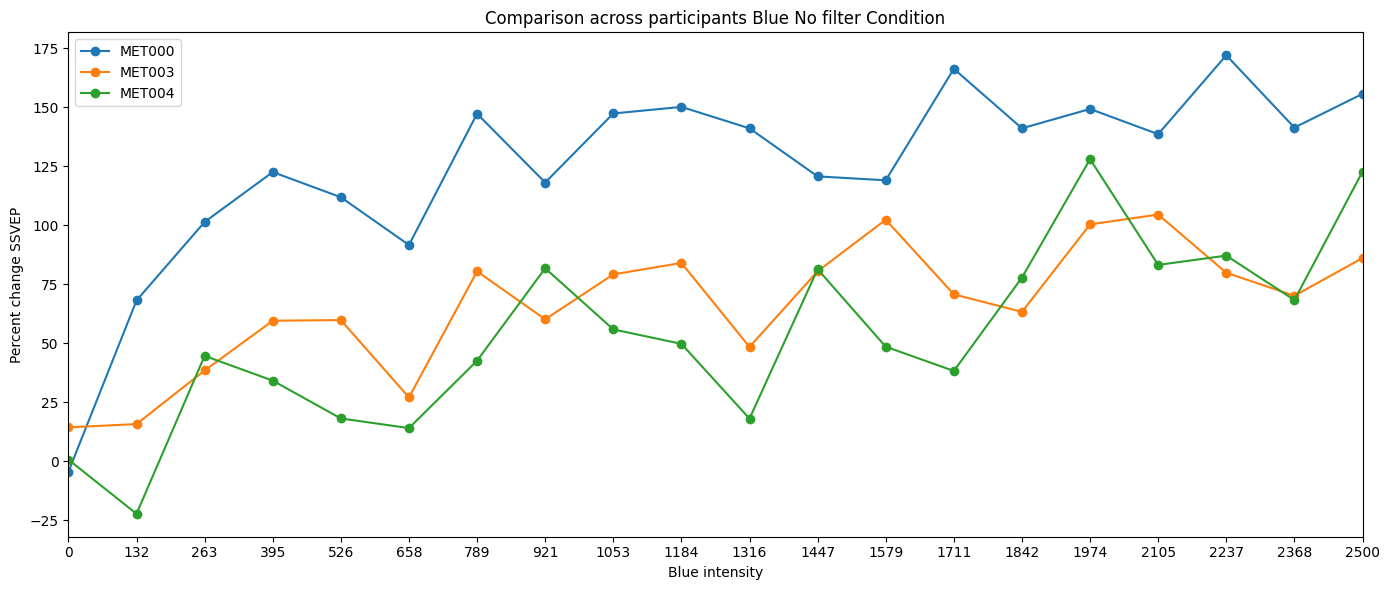

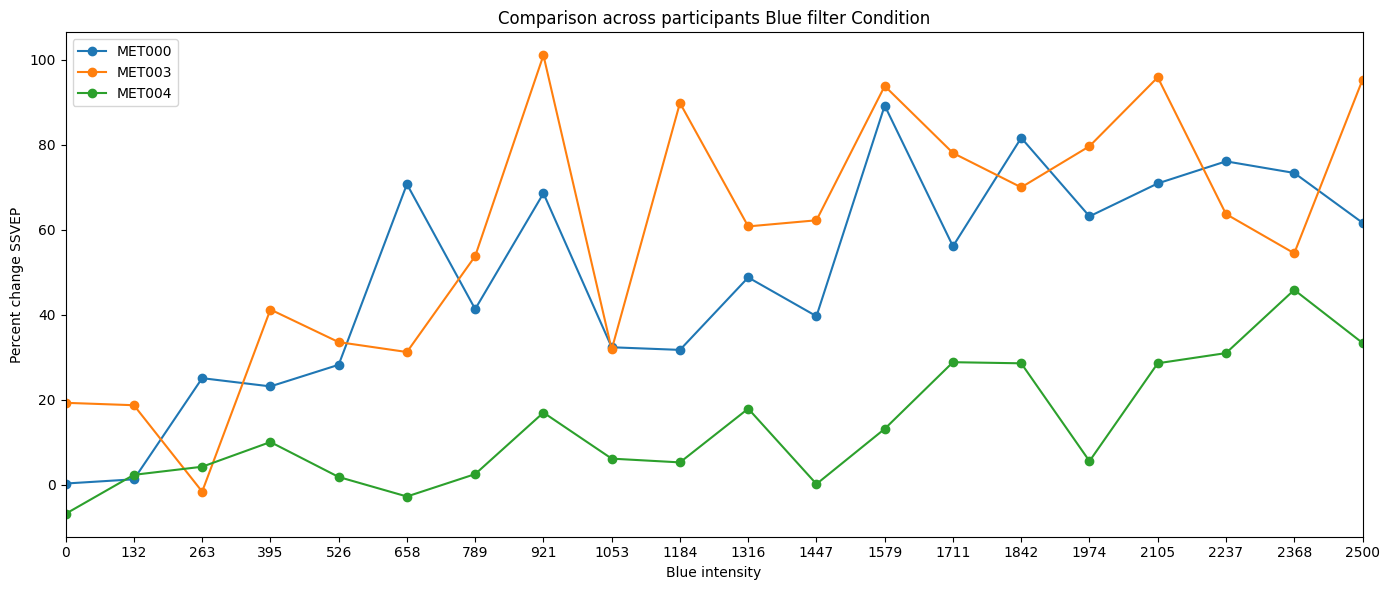

In [17]:
plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="B",
    title="Comparison across participants Blue No filter Condition"
)

plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BFi",
    title="Comparison across participants Blue filter Condition"
)


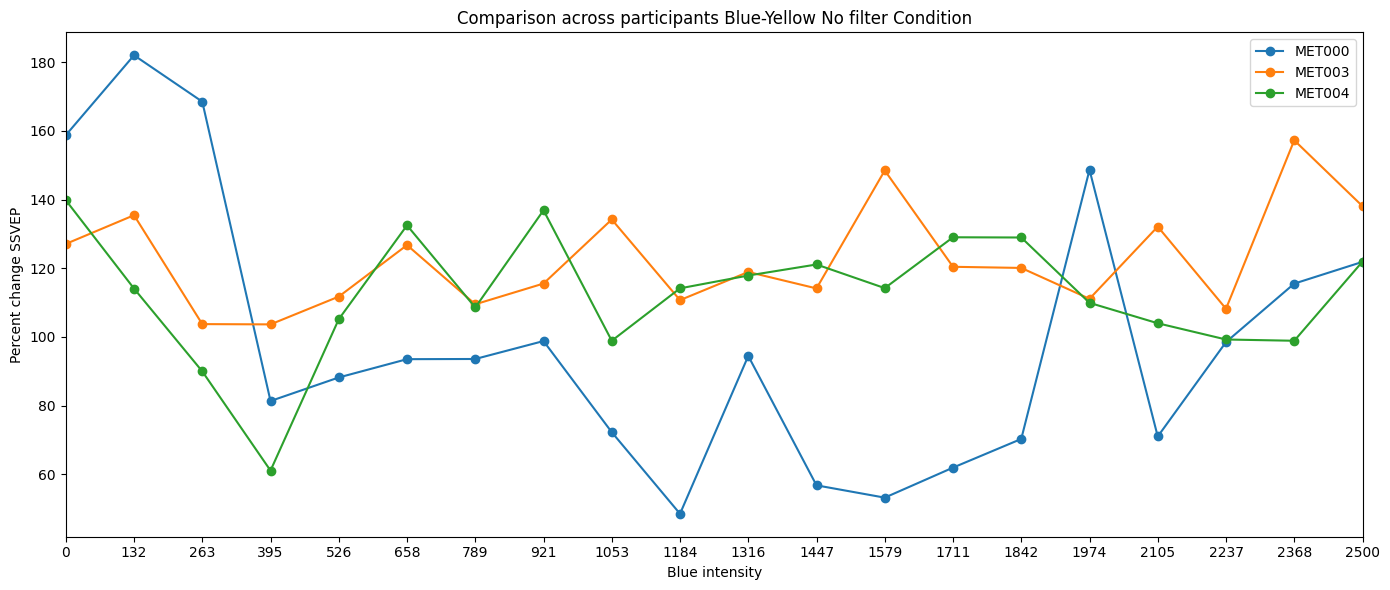

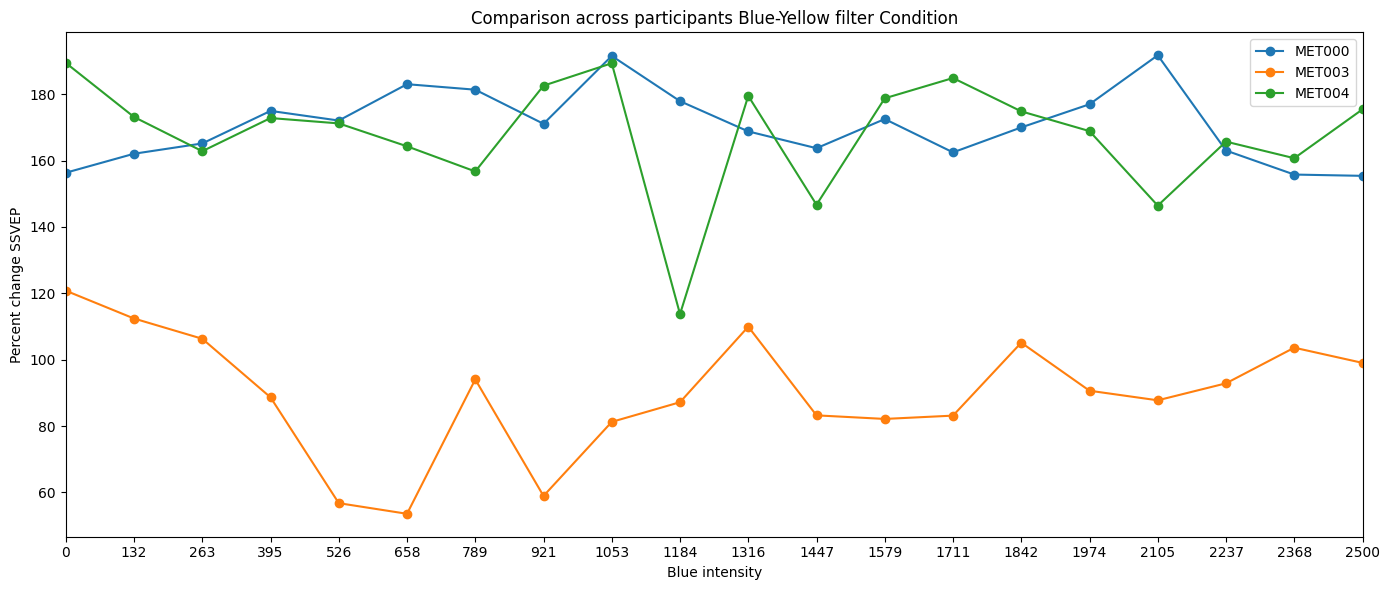

In [18]:
plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BY",
    title="Comparison across participants Blue-Yellow No filter Condition"
)

plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BYFi",
    title="Comparison across participants Blue-Yellow filter Condition"
)

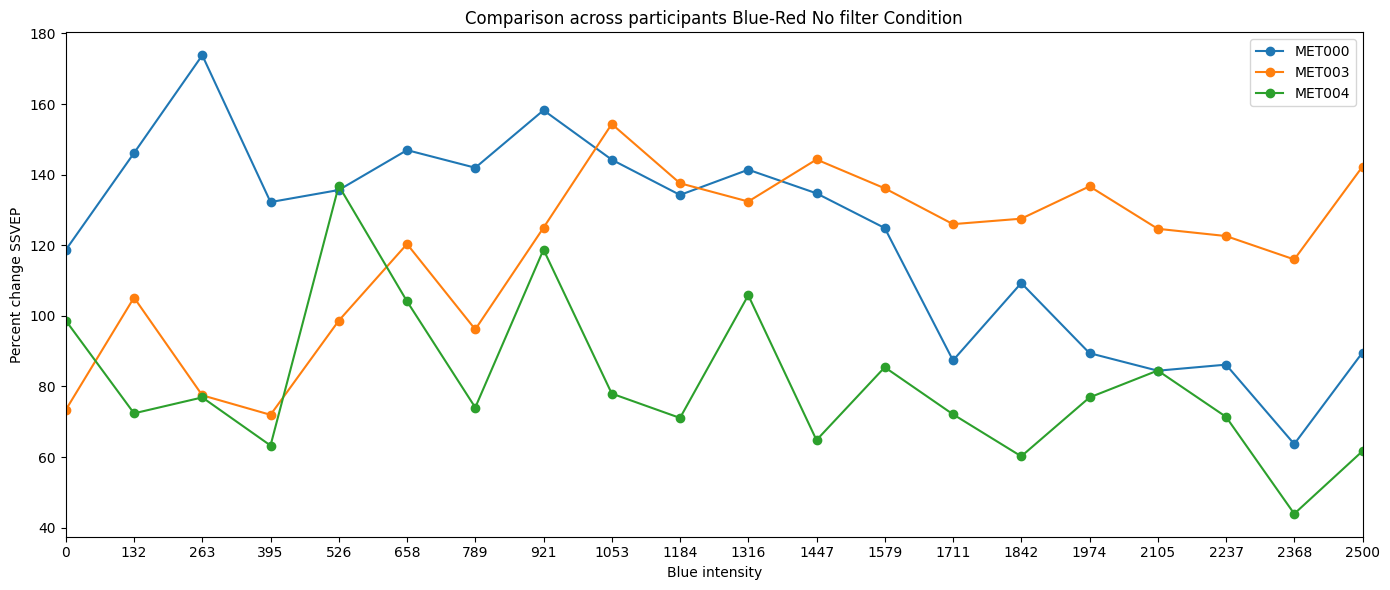

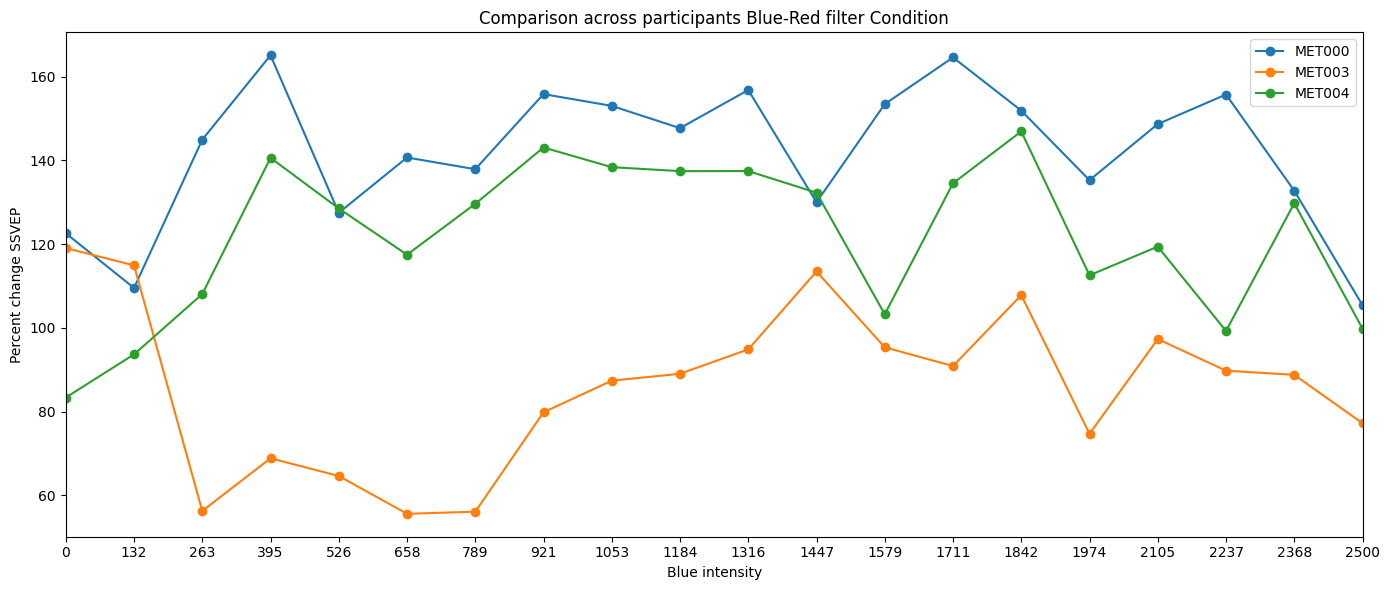

In [19]:
plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BR",
    title="Comparison across participants Blue-Red No filter Condition"
)

plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BRFi",
    title="Comparison across participants Blue-Red filter Condition"
)

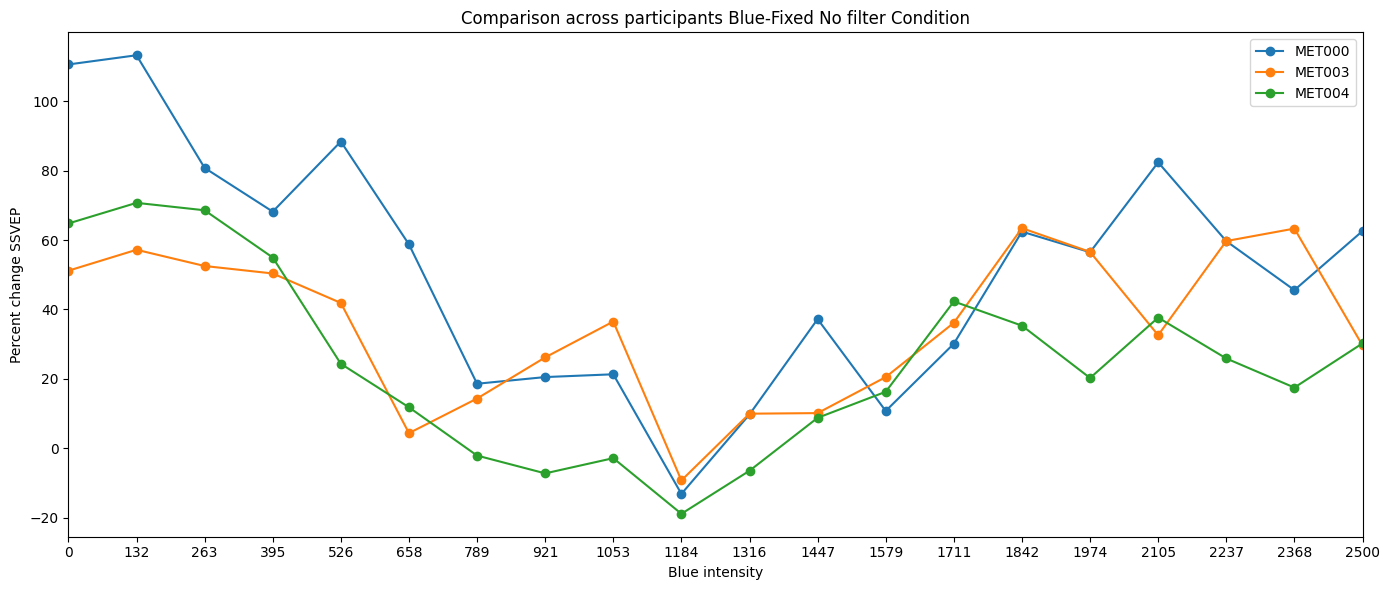

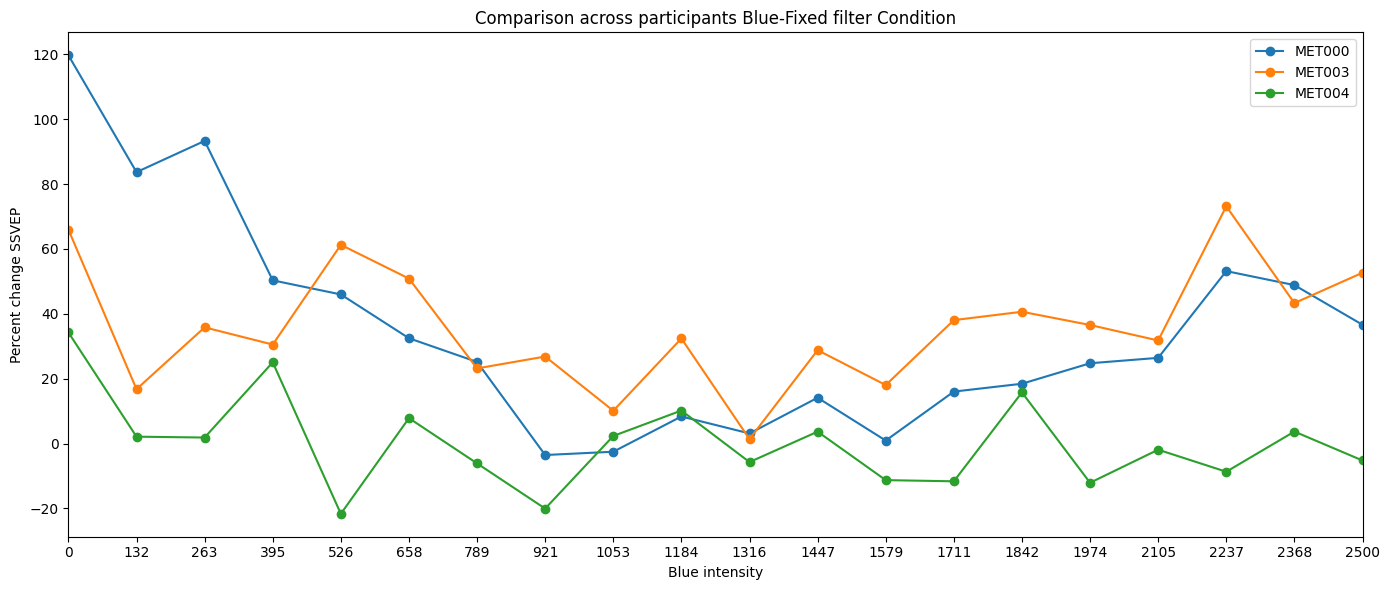

In [20]:
plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BF",
    title="Comparison across participants Blue-Fixed No filter Condition"
)

plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BFFi",
    title="Comparison across participants Blue-Fixed filter Condition"
)

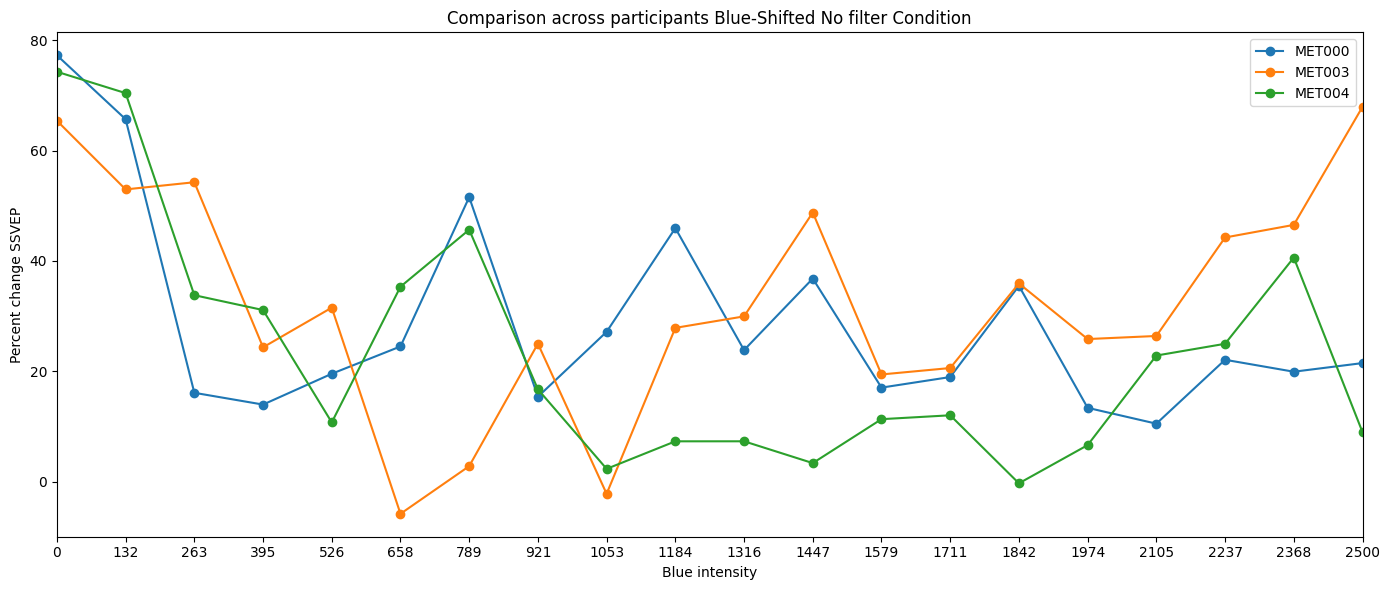

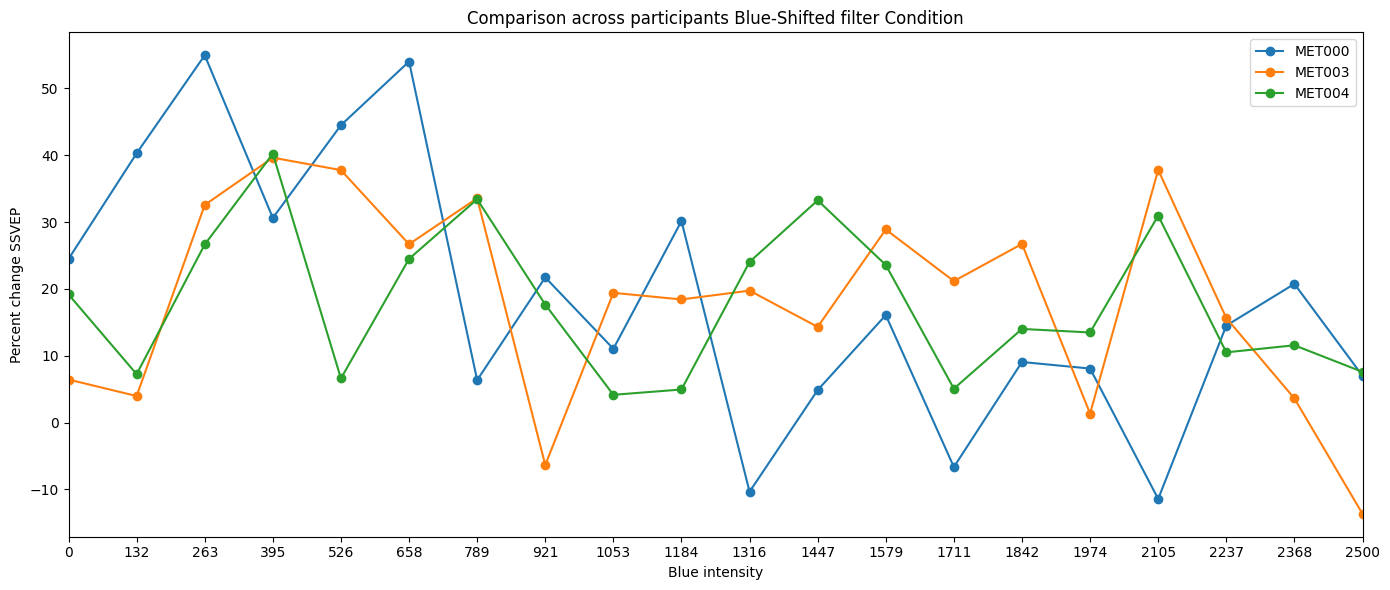

In [21]:
plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BS",
    title="Comparison across participants Blue-Shifted No filter Condition"
)

plot_condition_across_participants(
    [ssvep1, ssvep2, ssvep3],
    cond="BSFi",
    title="Comparison across participants Blue-Shifted filter Condition"
)